In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import platform

In [2]:
# 그래프 시각화에서 한글 깨짐 방지
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [3]:
df = pd.read_csv('../data2/creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [5]:
df[['Time', 'Amount']].describe()

,Time,Amount
count,284807.000000,284807.000000
mean,94813.859575,88.349619
std,47488.145955,250.120109
min,0.000000,0.000000
25%,54201.500000,5.600000
50%,84692.000000,22.000000
75%,139320.500000,77.165000
max,172792.000000,25691.160000


In [6]:
# Time column 데이터는 'Sec' → 'Hour'의 24시간 체계로 변환
df['Hour'] = (df['Time']//3600) % 24

In [7]:
df['Hour'].describe()

count    284807.000000
mean         14.046470
std           5.835854
min           0.000000
25%          10.000000
50%          15.000000
75%          19.000000
max          23.000000
Name: Hour, dtype: float64

In [8]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

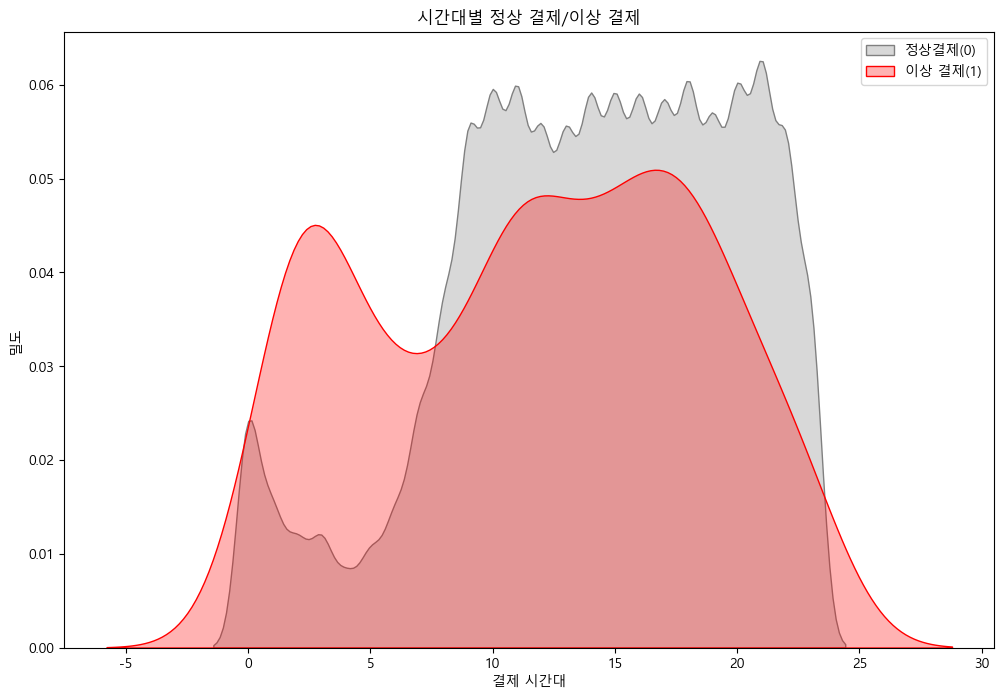

In [9]:
# 밀도 그래프

plt.figure(figsize=(12,8))
sns.kdeplot(df.loc[df['Class']==0, 'Hour'], label = '정상결제(0)', fill=True, alpha=0.3, color='gray')
sns.kdeplot(df.loc[df['Class']==1, 'Hour'], label = '이상 결제(1)', fill=True, alpha = 0.3, color='red')
plt.title('시간대별 정상 결제/이상 결제')
plt.xlabel('결제 시간대')
plt.ylabel('밀도')
plt.legend()
plt.show()

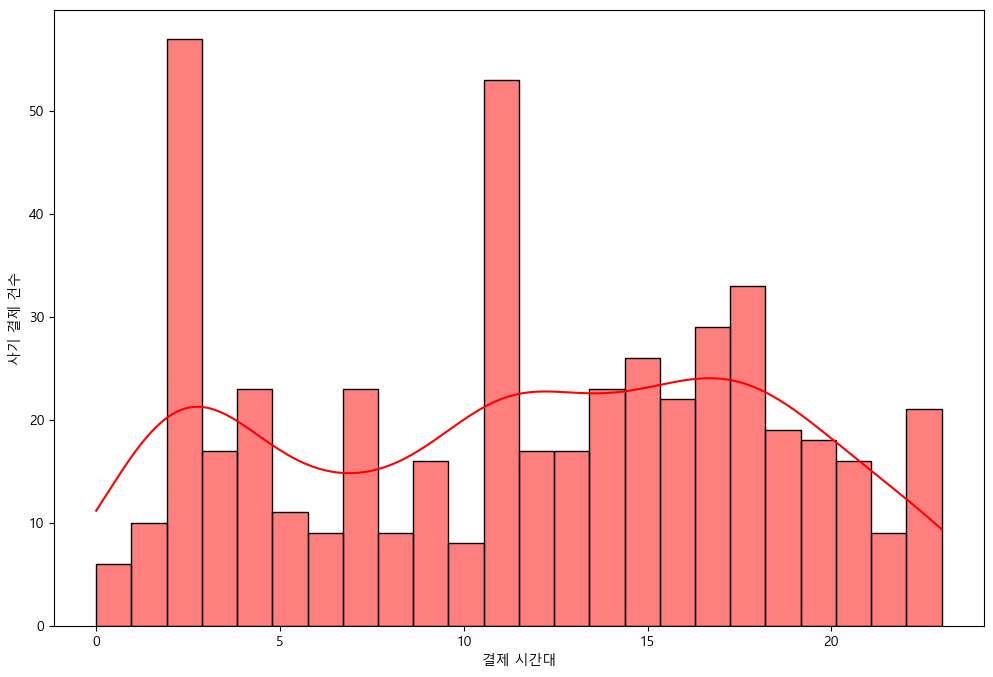

In [10]:
# 절대량 시각화

plt.figure(figsize = (12, 8))
sns.histplot(df.loc[df['Class']==1], x='Hour', bins = 24, color='red', kde = True)
plt.xlabel('결제 시간대')
plt.ylabel('사기 결제 건수')
plt.show()

In [11]:
# 결제 시간대별 전체 결제 건수 대비 사기 결제 건수의 비율
# 정상거래0 사기거래1 : 모든 데이터를 더하면 사기 거래의 건수
# 전체 데이터의 개수와 나눠주면? 됨? mean

group_df = (df.groupby('Hour')['Class'].mean() * 100)

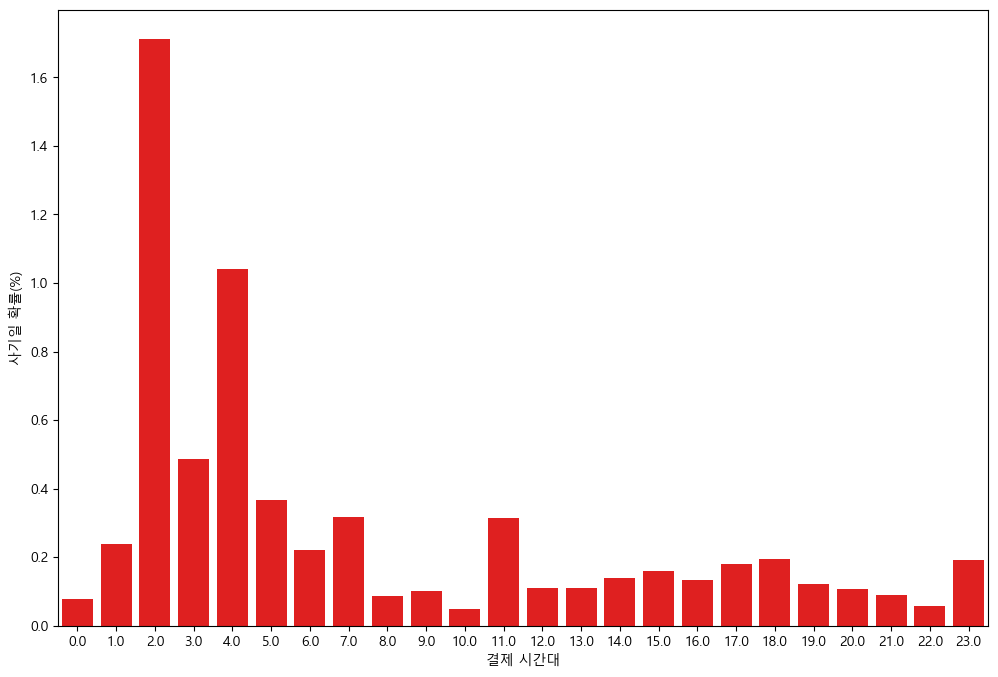

In [12]:
plt.figure(figsize = (12, 8))
sns.barplot(x=group_df.index, y=group_df.values, color='red')
plt.xlabel('결제 시간대')
plt.ylabel('사기일 확률(%)')
plt.show()

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler

In [14]:
# 시간 데이터와 class는 학습 데이터에서 제외
X = df.drop(['Class', 'Time'], axis=1)
y = df['Class']

In [15]:
scaler = StandardScaler()
X['Amount'] = scaler.fit_transform(X[['Amount']])

In [16]:
# 학습 / 검증 데이터로 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42, stratify = y)


In [17]:
print(f"Train Data에서 정상 거래 건수: {sum(y_train == 0)}, 사기 거래 건수: {sum(y_train == 1)}")

Train Data에서 정상 거래 건수: 227451, 사기 거래 건수: 394


In [18]:
# 로지스틱 일반 모델

model1 = LogisticRegression(max_iter = 1000)
model1.fit(X_train, y_train)
pred1 = model1.predict(X_test)

In [19]:
# 데이터 불균형 문제 해결: class_weight 매개변수 수정

model2 = LogisticRegression(max_iter = 1000, class_weight = 'balanced')
model2.fit(X_train, y_train)
pred2 = model2.predict(X_test)

In [20]:
print('일반 모델')
print(classification_report(y_test, pred1))
print()
print('밸런스 모델')
print(classification_report(y_test, pred2))

일반 모델
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.65      0.73        98

    accuracy                           1.00     56962
   macro avg       0.92      0.83      0.87     56962
weighted avg       1.00      1.00      1.00     56962


밸런스 모델
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.91      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.94      0.55     56962
weighted avg       1.00      0.97      0.99     56962



In [21]:
# 사기 거래 데이터에서 SMOTE를 이용하여 소수의 데이터를 늘려준다. → 1번 모델을 이용해서 학습, 예측

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state = 42)

In [22]:
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

In [23]:
print(f'SMOTE 후 정상 거래 개수: {sum(y_train_sm == 0)}, 사기 거래 건수: {sum(y_train_sm == 1)}')

SMOTE 후 정상 거래 개수: 227451, 사기 거래 건수: 227451


In [24]:
model1.fit(X_train_sm, y_train_sm)
pred_sm = model1.predict(X_test)

print('SMOTE 모델')
print(classification_report(y_test, pred_sm))

SMOTE 모델
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.05      0.91      0.10        98

    accuracy                           0.97     56962
   macro avg       0.53      0.94      0.54     56962
weighted avg       1.00      0.97      0.98     56962



In [25]:
# SHAP value 확인 (shap 라이브러리 설치)

# !pip install shap

In [26]:
import shap

c:\Users\hkssn\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [27]:
# SHAP 설명기 → 선형 모델용 LinearExplainer
explainer = shap.LinearExplainer(model2, X_train)

# 분석할 타겟 데이터를 선정 → 사기 결제 데이터중  첫번째 데이터 선택
target_data = X_test[y_test == 1].iloc[[0]]
target_data

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Hour
77348,-1.271244,2.462675,-2.851395,2.32448,-1.372245,-0.948196,-3.065234,1.166927,-2.268771,-4.881143,...,0.652941,0.081931,-0.221348,-0.523582,0.224228,0.756335,0.6328,0.250187,-0.353189,15.0


In [28]:
shap_value = explainer.shap_values(target_data)
shap_value

array([[-9.68703607e-01,  1.78969609e+00, -1.38794040e+00,
         2.55024933e+00, -1.45858642e+00,  6.54712439e-01,
         2.42642062e+00, -6.77135101e-01,  1.00042651e+00,
         6.59302652e+00,  1.67050636e+00,  6.47640848e+00,
        -2.79431213e-01,  1.00085434e+01, -8.10457984e-02,
         5.98734153e+00,  7.94945663e+00,  1.17037703e+00,
         5.25607389e-01, -1.01078297e+00,  4.10874619e-02,
         9.14483530e-02, -1.92687174e-01,  3.23868506e-02,
         1.00076590e-02, -2.45517394e-01, -3.04187555e-01,
         2.70427843e-01, -8.37545674e-01,  3.50888902e-02]])

c:\Users\hkssn\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\shap\plots\_waterfall.py:638: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  text_bbox = txt_obj.get_window_extent(renderer=renderer)
C:\Users\hkssn\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


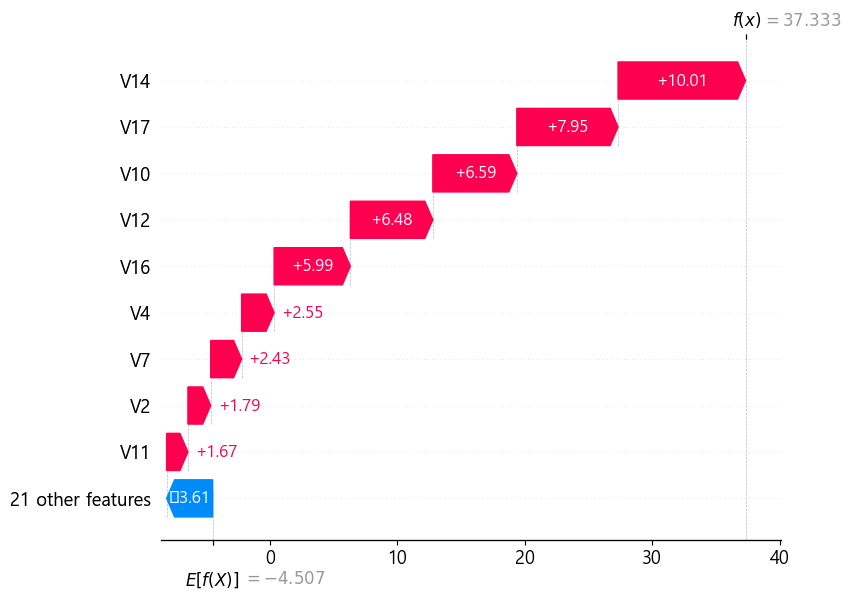

In [30]:
shap.plots._waterfall.waterfall_legacy(explainer.expected_value, shap_value[0], feature_names = X.columns)

In [31]:
# LIME 라이브러리 설치

# !pip install lime

In [32]:
import lime.lime_tabular as lime

# lime 설명기 초기화 (객체 생성)
explainer_lime = lime.LimeTabularExplainer(
    training_data = X_train.values,
    feature_names = X.columns,
    class_names = ['정상결제(0)', '사기결제(1)'],
    mode = 'classification',
    random_state = 42
)

In [33]:
target_data = X_test[y_test == 1].iloc[1]

In [34]:
exp = explainer_lime.explain_instance(
    data_row = target_data.values,
    predict_fn = model2.predict_proba,
    num_features = 5
)

c:\Users\hkssn\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


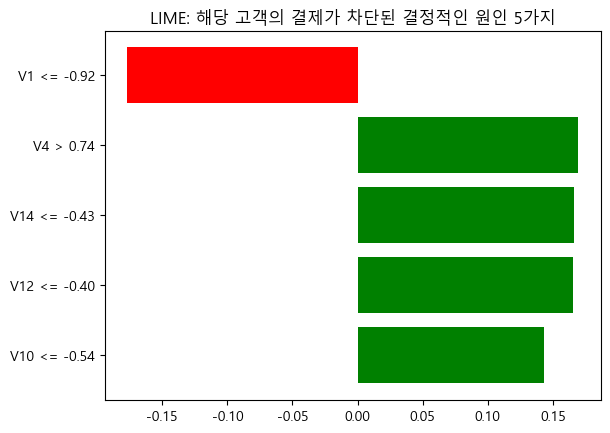

In [35]:
exp.as_pyplot_figure()
plt.title('LIME: 해당 고객의 결제가 차단된 결정적인 원인 5가지')
plt.show()

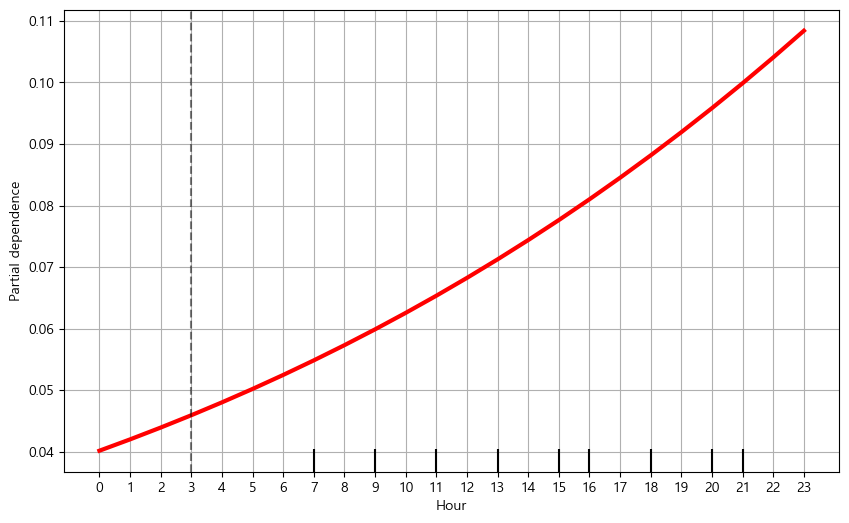

In [36]:
# PDP → 특정 컬럼이 변화할 때 예측값에 대해 영향력을 확인
from sklearn.inspection import PartialDependenceDisplay

# 결제 시간대가 사기 거래 판정 확률에 미치는 영향
fig, ax = plt.subplots(figsize = (10, 6))

pdp_display = PartialDependenceDisplay.from_estimator(
    estimator=model2, 
    X = X_train,
    features = ['Hour'],
    kind = 'average',
    ax = ax,
    line_kw = {'color': 'red', 'linewidth' : 3}
)

# 보조선 추가

plt.axvline(x=3, color='black', linestyle='--', alpha = 0.5)
plt.xticks(range(0, 24))
plt.grid()
plt.show()

In [37]:
from sklearn.ensemble import RandomForestClassifier

In [38]:
# 신이 돌아왔다.🥹

rf = RandomForestClassifier(random_state = 42, n_jobs = -1, class_weight = 'balanced_subsample')
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

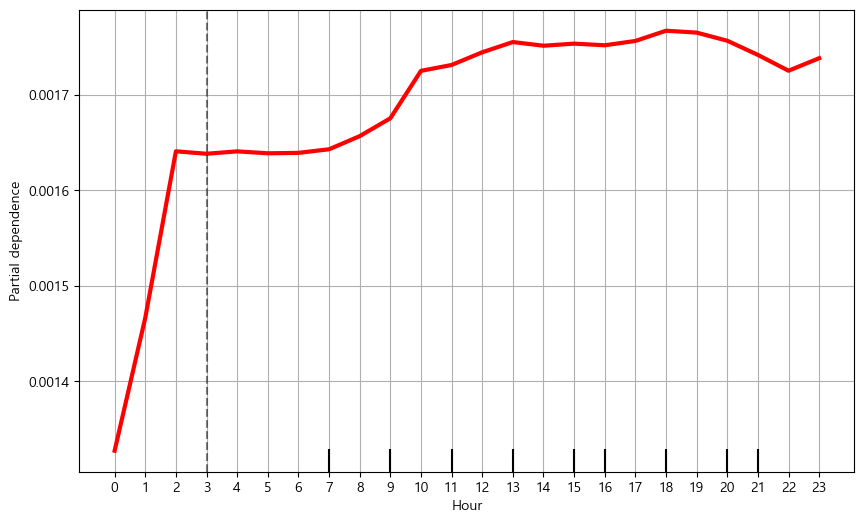

In [39]:
fig, ax = plt.subplots(figsize = (10, 6))

pdp_display = PartialDependenceDisplay.from_estimator(
    estimator=rf, 
    X = X_train,
    features = ['Hour'],
    kind = 'average',
    ax = ax,
    line_kw = {'color': 'red', 'linewidth' : 3}
)

# 보조선 추가

plt.axvline(x=3, color='black', linestyle='--', alpha = 0.5)
plt.xticks(range(0, 24))
plt.grid()
plt.show()